In [127]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242)

features = energy_efficiency.data.features
selected_columns = energy_efficiency.data.targets
heating_column = selected_columns['Y1']
cooling_column = selected_columns['Y2']

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y1_train, y1_test = train_test_split(features, heating_column, test_size=0.2, random_state=1111)
_, _, y2_train, y2_test = train_test_split(features, cooling_column, test_size=0.2, random_state=1111)

In [129]:
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

def print_statistics(y_test, y_pred, model_name):
    print(f"\n{model_name}:")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Предсказания')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red',
    label='Идеальная линия')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказанные значения')
    plt.title(title)
    plt.legend()
    plt.show()

In [130]:
models_results = []


Linear Model (Y1):
MSE: 9.1250


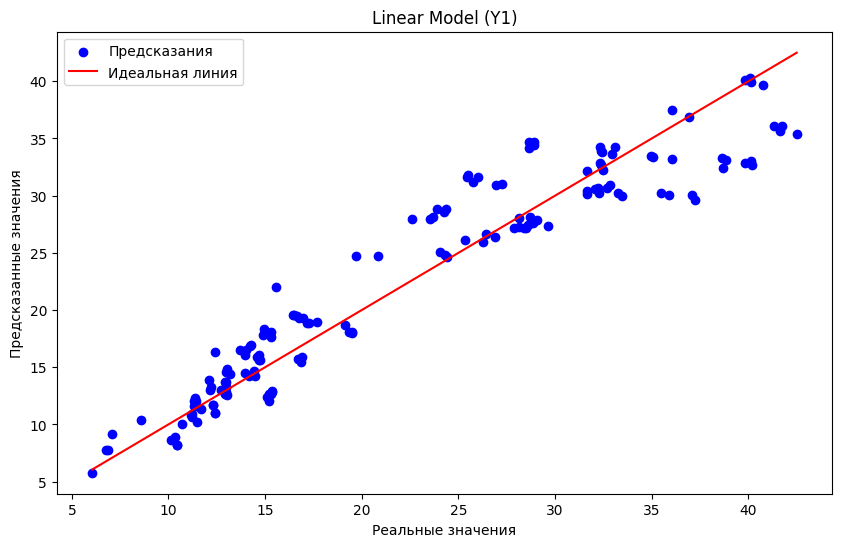


Linear Model (Y2):
MSE: 12.7634


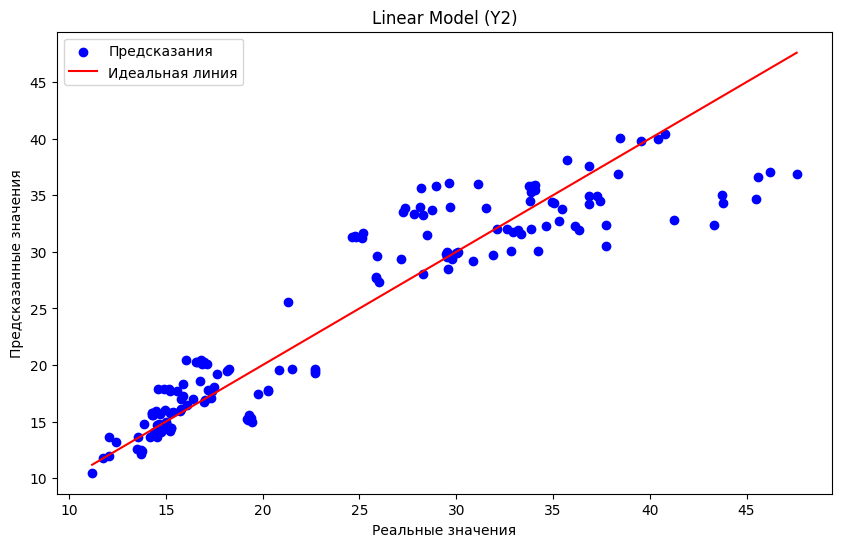

In [132]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y1_train)
y1_pred_lm = lm.predict(X_test)
print_statistics(y1_test, y1_pred_lm, "Linear Model (Y1)")
plot_predictions(y1_test, y1_pred_lm, "Linear Model (Y1)")

lm.fit(X_train, y2_train)
y2_pred_lm = lm.predict(X_test)
print_statistics(y2_test, y2_pred_lm, "Linear Model (Y2)")
plot_predictions(y2_test, y2_pred_lm, "Linear Model (Y2)")
models_results.append([[y1_test, y1_pred_lm], [y2_test, y2_pred_lm]])


Generalized Linear Model (Y1):
MSE: 9.1889


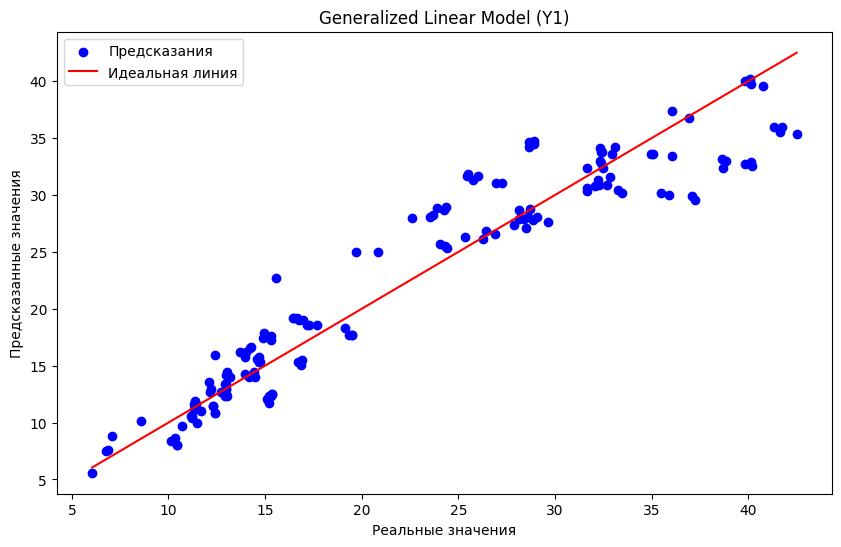


Generalized Linear Model (Y2):
MSE: 12.7426


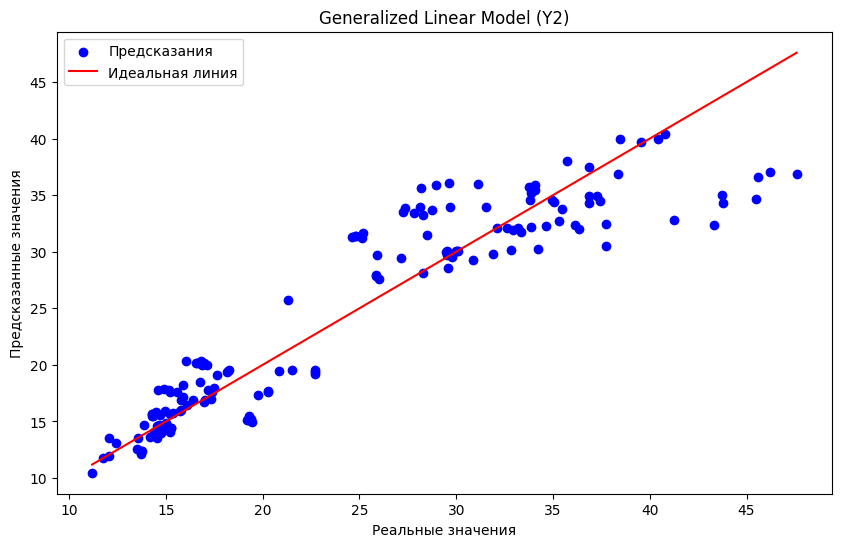

In [133]:
import statsmodels.api as sm

glm = sm.GLM(y1_train, sm.add_constant(X_train), family=sm.families.Gaussian())
res = glm.fit()
y1_pred_glm = res.predict(sm.add_constant(X_test))
print_statistics(y1_test, y1_pred_glm, "Generalized Linear Model (Y1)")
plot_predictions(y1_test, y1_pred_glm, "Generalized Linear Model (Y1)")

glm = sm.GLM(y2_train, sm.add_constant(X_train), family=sm.families.Gaussian())
res = glm.fit()
y2_pred_glm = res.predict(sm.add_constant(X_test))
print_statistics(y2_test, y2_pred_glm, "Generalized Linear Model (Y2)")
plot_predictions(y2_test, y2_pred_glm, "Generalized Linear Model (Y2)")
models_results.append([[y1_test, y1_pred_glm], [y2_test, y2_pred_glm]])


Non-linear Model (Y1):
MSE: 4.7880


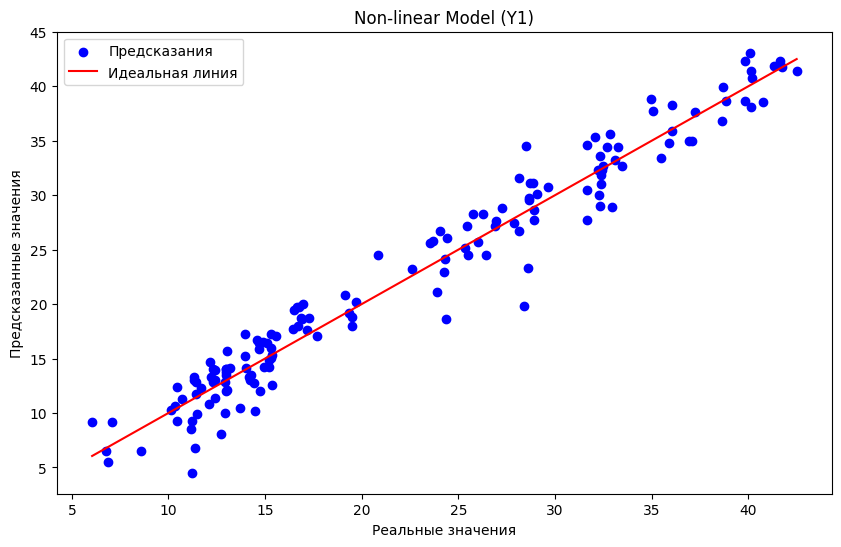


Non-linear Model (Y2):
MSE: 15.8828


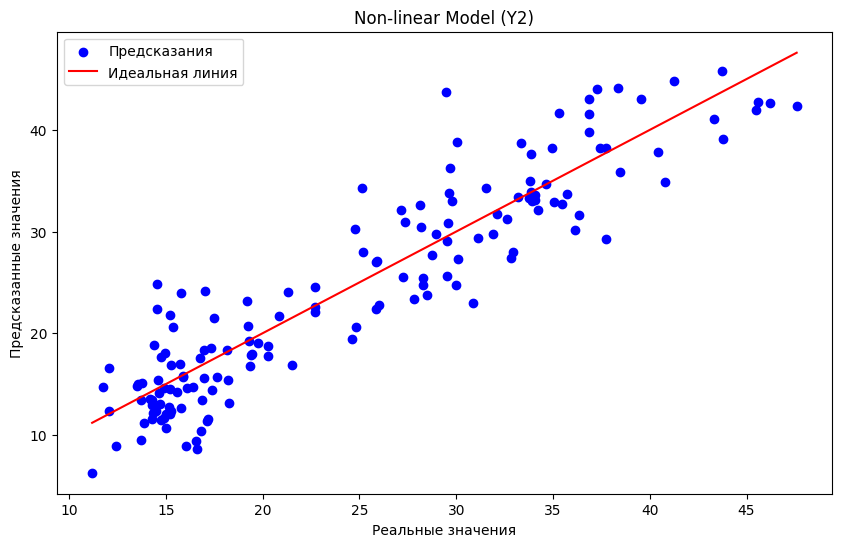

In [134]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y1_train)
y1_pred_nlm = poly_model.predict(X_test)
print_statistics(y1_test, y1_pred_nlm, "Non-linear Model (Y1)")
plot_predictions(y1_test, y1_pred_nlm, "Non-linear Model (Y1)")

poly_model.fit(X_train, y2_train)
y2_pred_nlm = poly_model.predict(X_test)
print_statistics(y2_test, y2_pred_nlm, "Non-linear Model (Y2)")
plot_predictions(y2_test, y2_pred_nlm, "Non-linear Model (Y2)")
models_results.append([[y1_test, y1_pred_nlm], [y2_test, y2_pred_nlm]])


Neural model (Y1):
MSE: 13.7109


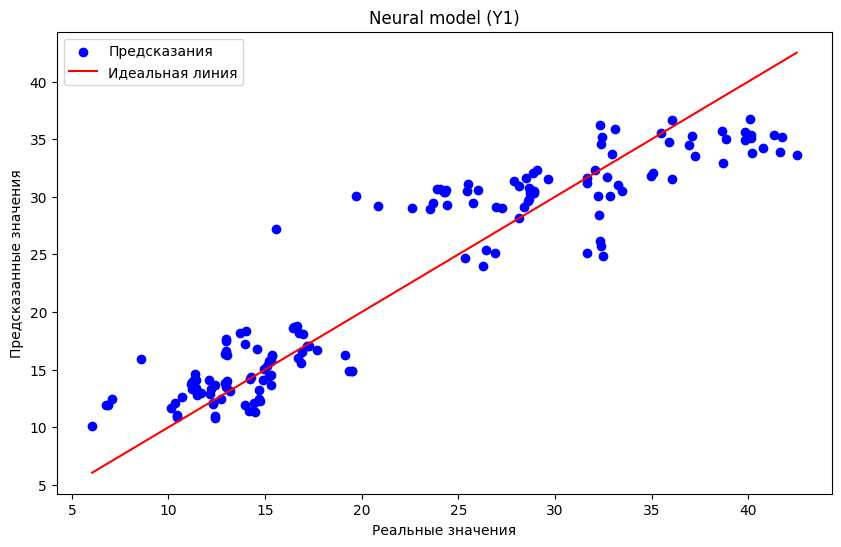


Neural model (Y2):
MSE: 16.7191


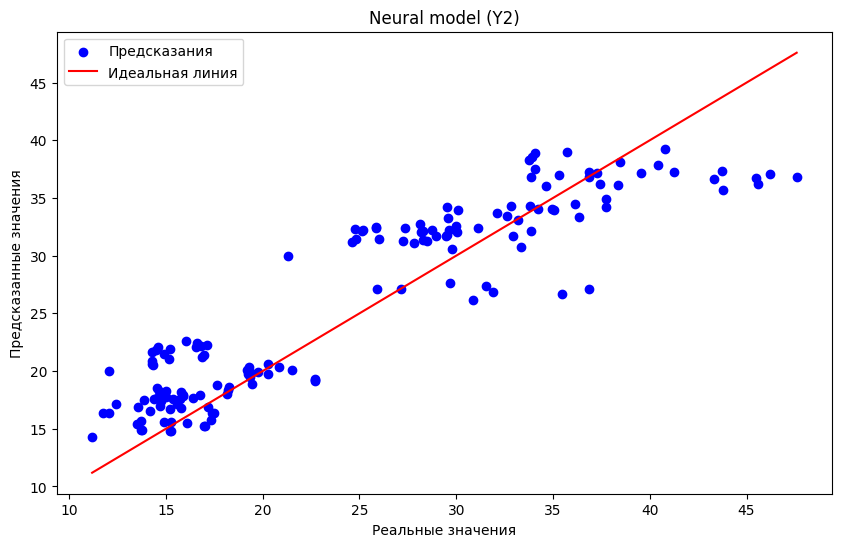

In [135]:
from sklearn.neural_network import MLPRegressor

mlp_reg = MLPRegressor(hidden_layer_sizes=(100, 50, 20), activation='relu', solver='adam', max_iter=1000, random_state=1111)
mlp_reg.fit(X_train, y1_train)
y1_pred = mlp_reg.predict(X_test)
print_statistics(y1_test, y1_pred, "Neural model (Y1)")
plot_predictions(y1_test, y1_pred, "Neural model (Y1)")

mlp_reg.fit(X_train, y2_train)
y2_pred = mlp_reg.predict(X_test)
print_statistics(y2_test, y2_pred, "Neural model (Y2)")
plot_predictions(y2_test, y2_pred, "Neural model (Y2)")
models_results.append([[y1_test, y1_pred], [y2_test, y2_pred]])

In [136]:
from sklearn.metrics import max_error, mean_absolute_error, mean_absolute_percentage_error

def metrics(y_test, y_pred):
    return {
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        'Max Error': max_error(y_test, y_pred)
    }

In [190]:
data = []
y1MSEs = []
y2MSEs = []

models = ['lm', 'glm', 'nlm', 'neuro']

for index, model in enumerate(models):
    for metric in ['MSE', 'MAE', 'MAPE', 'Max Error']:
        if metric == 'MSE':
            y1MSEs.append({model: metrics(models_results[index][0][0], models_results[index][1][1])[metric]})
            y2MSEs.append({model: metrics(models_results[index][0][1], models_results[index][1][1])[metric]})

        data.append([
            model, metric, 
            metrics(models_results[index][0][0], models_results[index][1][1])[metric], 
            metrics(models_results[index][0][1], models_results[index][1][1])[metric]
        ])

columns = ['Model', 'Metric', 'Y1', 'Y2']
table = pd.DataFrame(data, columns=columns)
table

,Model,Metric,Y1,Y2
0,lm,MSE,15.354373,5.677046
1,lm,MAE,3.235178,2.187619
2,lm,MAPE,0.183229,0.135753
3,lm,Max Error,9.981263,4.712130
4,glm,MSE,15.233535,6.041638
5,glm,MAE,3.211573,2.255024
6,glm,MAPE,0.181038,0.145234
7,glm,Max Error,10.155225,4.874776
8,nlm,MSE,21.105286,40.171045
9,nlm,MAE,3.489130,4.793074


In [188]:
def min_value(arr):
    min_model = None
    min_value = float('inf')

    for dict in arr:
        for model, value in dict.items():
            if value < min_value:
                min_value = value
                min_model = model

    return {min_model: min_value}

In [192]:
print(f"Smallest MSE for Heating Load: {min_value(y1MSEs)}")
print(f"Smallest MSE for Cooling Load: {min_value(y2MSEs)}")

Smallest MSE for Heating Load: {'glm': np.float64(15.233534784677948)}
Smallest MSE for Cooling Load: {'lm': np.float64(5.6770455595411216)}
